# `epscontrol` tutorial — control effect functions and multi-parameter persistence

This notebook walks through the library implementing

> Y. Imoto and T. Yokoyama, *Multi-parameter persistence in dynamical systems for maximizing effects of control inputs*, [arXiv:2606.05577](https://arxiv.org/abs/2606.05577).

**The problem.** You have an **ensemble** of time series — many runs of the same dynamical system from slightly different initial states — and a scalar **evaluation function** telling you how good each run's *final* outcome was. The evaluation is therefore a **partial** function: it is defined only at the terminal times, and says nothing about the intermediate states that led there.

**The question.** Standing at some intermediate state, how good an outcome could I still reach if I were allowed to nudge the system — and how large a nudge would it take? The $\varepsilon$-**control effect function** answers this and, in doing so, extends the partial evaluation to the whole state space:

$$h_f^{\varepsilon\text{-}\ell^p}(x) \;=\; \inf h\bigl([x]^{\varepsilon\text{-}\ell^p}_f \cap \operatorname{dom} h\bigr),$$

the best value of $h$ reachable from $x$ using control inputs whose magnitudes have $\ell^p$ norm at most $\varepsilon$.

**Contents**

1. Input format: an ensemble as an `AnnData` object
2. The paper's example, and Example 1 reproduced
3. The role of $p$: bounding each input ($p=\infty$) versus their total ($p=1$)
4. Minimizing controlled paths
5. The $-\varepsilon$ branch: what an adversarial control can force
6. The difference effect function: where control pays off
7. The three-parameter filtration $(p, \varepsilon, \delta)$
8. A larger synthetic ensemble

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import epscontrol as ec

print("epscontrol", ec.__version__)


epscontrol 0.2.0


## 1. Input format: an ensemble as an `AnnData` object

The library follows the same convention as [`epsbasin`](https://github.com/yusuke-imoto-lab/eps-attracting-basin): `.X` holds the **states**, one row per (ensemble member, time) pair, and `.obs` carries the bookkeeping.

| slot | key | contents |
|---|---|---|
| `.X` | — | states, `n_obs × d` |
| `.obs` | `seq_id` | which ensemble member the row belongs to |
| `.obs` | `time` | the row's order within its member |
| `.obs` | `h` | the evaluation, at each member's **terminal** row only (`NaN` elsewhere) |
| `.uns` | `cost_matrix` | optional precomputed cost matrix $c$ |
| `.obsm` | `plot_data` | optional 2-D coordinates for plotting |

`from_ensemble` assembles this from a list of per-member arrays plus one evaluation per member. Members may have different lengths.

In [2]:
adata_toy = ec.from_ensemble(
    [
        np.array([[1.0, 6.0], [5.0, 6.0], [9.0, 9.0]]),   # member 0
        np.array([[1.0, 5.0], [5.0, 5.0], [9.0, 2.0]]),   # member 1
    ],
    values=[9.0, 2.0],          # h at the terminal time of each member
    var_names=["x1", "x2"],
)
adata_toy

AnnData object with n_obs × n_vars = 6 × 2
    obs: 'seq_id', 'time', 'h'
    layers: None (.X)

In [3]:
adata_toy.obs

,seq_id,time,h
0,0,0,NaN
1,0,1,NaN
2,0,2,9.0
3,1,0,NaN
4,1,1,NaN
5,1,2,2.0


The dynamical system is implicit in the data: it is the **shift along each member**, $f(y^{(i)}_t) = y^{(i)}_{t+1}$. So $\operatorname{dom} f$ is every non-terminal point and $\operatorname{dom} h$ every terminal point, which is exactly the paper's hypothesis

$$X = \operatorname{dom} f \sqcup \operatorname{dom} h = \bigsqcup_{n \ge 0} f^{-n}(\operatorname{dom} h).$$

`check_hypotheses` verifies this and the two conditions the theorems add.

In [4]:
ec.check_hypotheses(adata_toy)

{'disjoint_domains': True, 'covers_X': True, 'preimage_decomposition': True, 'dom_h_fixed': True}

## 2. The paper's example

`datasets.paper_example()` builds the branching system of Figures 2 and 3. Five orbits start at $(0, x_2)^{\mathsf T}$ for $x_2 \in \{6,5,4,3,2\}$ and are iterated three times under

$$f\bigl((x_1,x_2)^{\mathsf T}\bigr) = \begin{cases}(x_1+3,\; x_2-1)^{\mathsf T} & x_1 \ge 3 \wedge x_2 < 5,\\ (x_1+3,\; x_2)^{\mathsf T} & \text{otherwise.}\end{cases}$$

The dynamics translate right and, past an intermediate region, split into an upper branch holding its height and a lower branch descending. The evaluation is the terminal height, $h((x_1,x_2)^{\mathsf T}) = x_2$ on $x_1 = 9$, so **small $h$ is the desirable outcome** — here, ending up low.

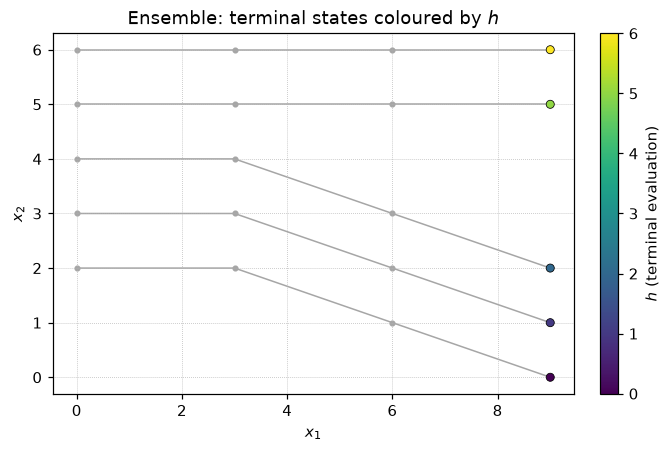

In [5]:
adata = ec.datasets.paper_example()

fig, ax = ec.plot_ensemble(adata, figsize=(6, 4))
ax.set_title("Ensemble: terminal states coloured by $h$")
fig.savefig("fig_ensemble.png", dpi=150, bbox_inches="tight")

The **cost function** prices a control input. The default is Euclidean *within a time layer* and $\infty$ across layers: at a given time you may pay to move to a state another ensemble member occupies at that same time, but you cannot jump forward or backward in time. On this example that reproduces the paper's

$$c\bigl((x_1,x_2)^{\mathsf T},(x_1',x_2')^{\mathsf T}\bigr) = \begin{cases}|x_2-x_2'| & x_1 = x_1',\\ \infty & \text{otherwise.}\end{cases}$$

`build_problem` assembles the problem $(X, f, c, h, p)$. Build it once and pass it as `problem=` to every analysis so the shortest paths are solved a single time.

In [6]:
prob_1 = ec.build_problem(adata, p=1.0)         # bounds the *total* control
prob_inf = ec.build_problem(adata, p=np.inf)    # bounds *each* control input

prob_inf.n, prob_inf.solver, prob_inf.levels

(20, 'layered', array([0., 1., 2., 5., 6.]))

`solver` reports `'layered'`: because control jumps stay within a time layer, the transition graph is a DAG graded by time and the effect function is computed by exact backward dynamic programming. With costs that connect different times the library falls back to Dijkstra in a min-plus ($p<\infty$) or min-max ($p=\infty$) semiring. Either way the values are **exact** — there is no sweep over an $\varepsilon$ grid.

`levels` are the attained values $\operatorname{Im} h = \{0,1,2,5,6\}$: the five outcomes this ensemble actually realizes.

### Example 1 of the paper

For the initial state $x = (0,6)^{\mathsf T}$ — row 0 — the paper records specific values. Let us reproduce them.

In [7]:
import pandas as pd

rows = []
for eps in (0.0, 1.0, 2.0):
    rows.append({
        "eps": eps,
        "h_f^{eps-l^1}": prob_1.control_effect(eps)[0],
        "h_f^{eps-l^inf}": prob_inf.control_effect(eps)[0],
        "h_f^{D eps-l^1}": prob_1.effect_difference(eps)[0],
        "h_f^{D eps-l^inf}": prob_inf.effect_difference(eps)[0],
    })
pd.DataFrame(rows).set_index("eps")

,h_f^{eps-l^1},h_f^{eps-l^inf},h_f^{D eps-l^1},h_f^{D eps-l^inf}
eps,,,,
0.0,6.0,6.0,0.0,0.0
1.0,5.0,1.0,-1.0,-5.0
2.0,2.0,0.0,-4.0,-6.0


These match Example 1 exactly: $h_f^{\varepsilon\text{-}\ell^1}(x) = 6, 5, 2$ and $h_f^{\varepsilon\text{-}\ell^\infty}(x) = 6, 1, 0$ for $\varepsilon = 0, 1, 2$, with differences $0, -1, -4$ and $0, -5, -6$. (The test suite asserts them, along with the reachable ranges and controllability values of Figure 3b.)

Read the first column: with **no** control the orbit from $(0,6)^{\mathsf T}$ stays on the upper branch and ends at height 6. One unit of total control buys height 5; two units buy height 2 — the descending branch becomes reachable.

### Computing for the whole ensemble

`control_effect` writes a column per budget into `adata.obs`.

In [8]:
ec.control_effect(adata, [0.0, 1.0, 2.0], problem=prob_inf)
ec.control_effect(adata, [0.0, 1.0, 2.0], problem=prob_1)

[c for c in adata.obs.columns if c.startswith("control_effect")]

['control_effect_eps0_pinf', 'control_effect_eps1_pinf', 'control_effect_eps2_pinf', 'control_effect_eps0_p1', 'control_effect_eps1_p1', 'control_effect_eps2_p1']

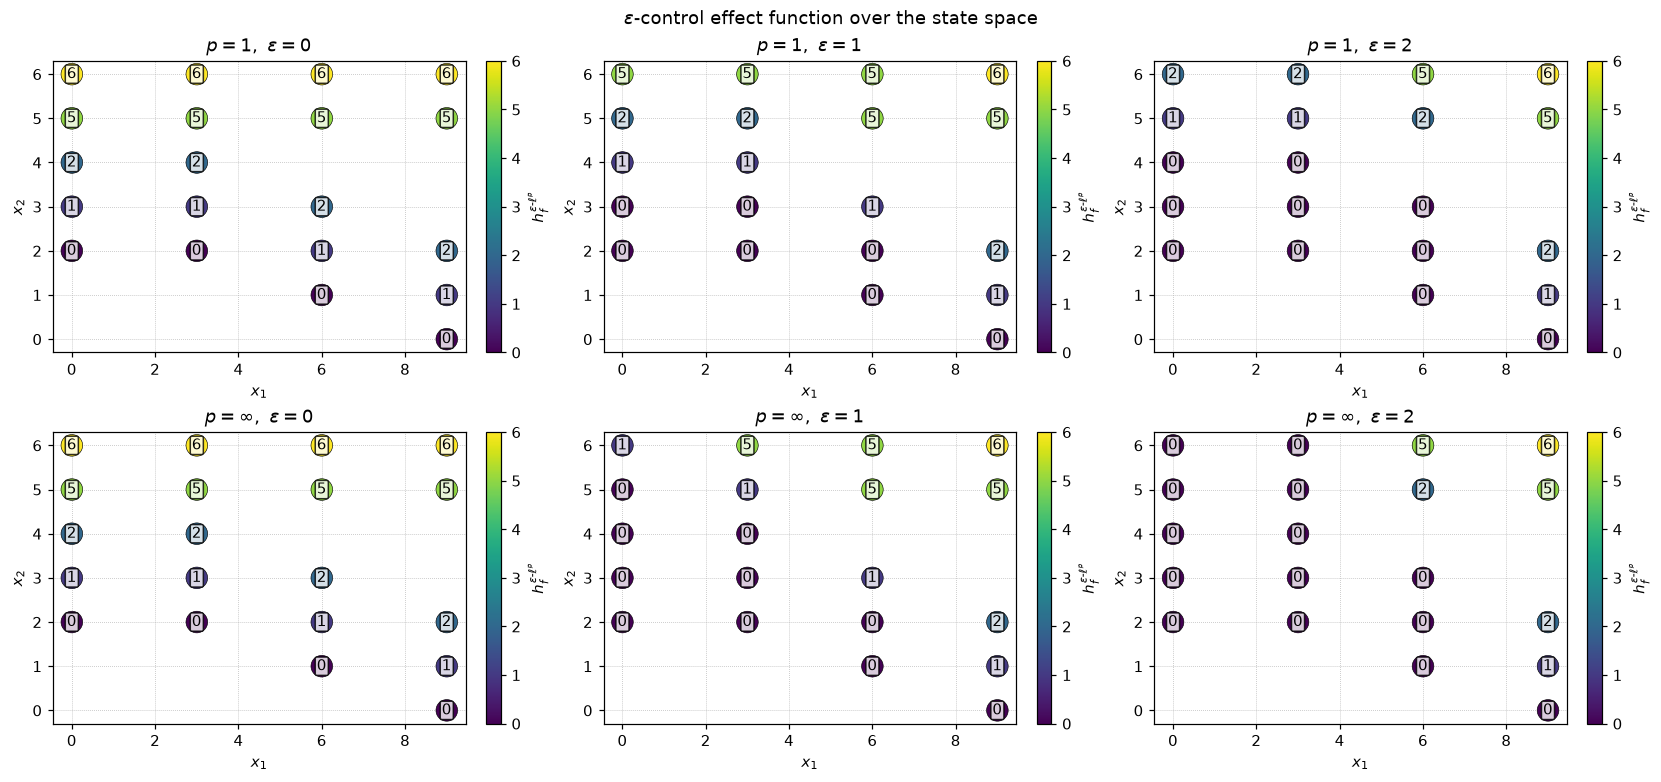

In [9]:
def annotate_values(ax, pts, values, fmt="{:.1g}", fontsize=10):
    for (x, y), v in zip(pts, values):
        ax.text(
            x,
            y,
            fmt.format(v),
            fontsize=fontsize,
            ha="center",
            va="center",
            color="k",
            bbox=dict(boxstyle="round,pad=0.1", fc="w", alpha=0.8),
            zorder=4,
        )

fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
for j, eps in enumerate((0.0, 1.0, 2.0)):
    for i, (p, prob) in enumerate((("1", prob_1), (r"\infty", prob_inf))):
        key = ec.result_key(eps, prob.p)
        fig, ax = ec.plot_effect(
            adata,
            key,
            ax=axes[i, j],
            cmap="viridis",
            label=r"$h_f^{\varepsilon\text{-}\ell^p}$",
            pointsize=200.0,
        )
        pts = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
        pts = np.asarray(pts, dtype=np.float64)[:, :2]
        values = adata.obs[key].to_numpy(dtype=np.float64)
        valid = np.isfinite(values)
        annotate_values(ax, pts[valid], values[valid])
        axes[i, j].set_title(rf"$p={p},\ \varepsilon={eps:g}$")
fig.suptitle(r"$\varepsilon$-control effect function over the state space")
fig.savefig("fig_effect_grid.png", dpi=150, bbox_inches="tight")


Each panel colours every state by the best outcome still reachable from it. Moving right along a row (larger budget) the colours cool: more control, better attainable outcomes, as Lemma 3.7 requires. Comparing the two rows at fixed $\varepsilon$ shows the effect of the norm.

## 3. The role of $p$

The norm parameter decides how a budget is *accounted*:

* $p = \infty$ — the constraint is $\max_i \varepsilon_i \le \varepsilon$: **each individual** input is capped, but you may spend that much at *every* time step. A generous regime.
* $p = 1$ — the constraint is $\sum_i \varepsilon_i \le \varepsilon$: the **total** control energy over the whole trajectory is capped. A strict regime.
* $1 < p < \infty$ interpolates.

Since $\|\cdot\|_{p'} \le \|\cdot\|_p$ for $p \le p'$, a path admissible at $p$ is admissible at $p' \ge p$, so the effect function is weakly decreasing in $p$ (Lemma 3.9): larger $p$ can only help. `plot_effect_curve` shows $\varepsilon \mapsto h_f(p, \varepsilon, x)$ for several $p$ at once.

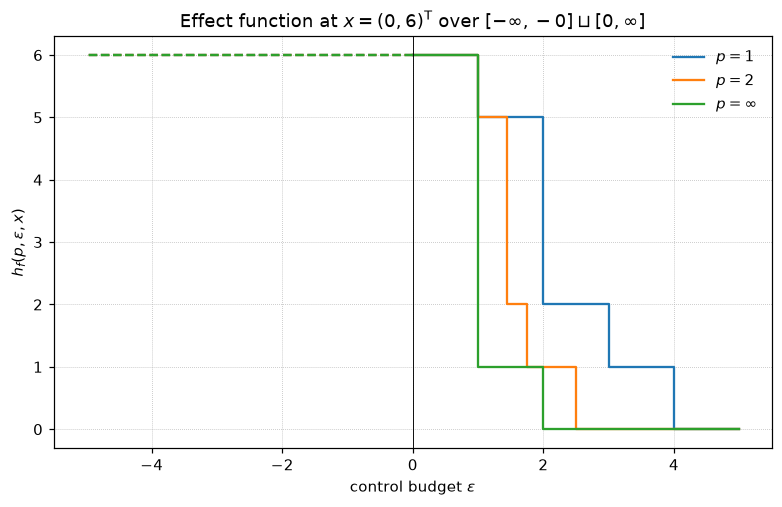

In [10]:
fig, ax = ec.plot_effect_curve(prob_inf, 0, ps=(1.0, 2.0, np.inf), signed=True, figsize=(7, 4.5))
ax.set_title(r"Effect function at $x=(0,6)^{\mathsf{T}}$ over $[-\infty,-0]\sqcup[0,\infty]$")
fig.savefig("fig_effect_curve.png", dpi=150, bbox_inches="tight")

Solid curves are the $\varepsilon \ge 0$ branch (best attainable outcome, decreasing), dashed curves the $-\varepsilon$ branch of Definition 14 (worst outcome an adversary can force, increasing). The two meet at $\varepsilon = 0$, where no control is applied — Lemma 3.6, since $\operatorname{dom} h$ and $\operatorname{dom} f$ are disjoint here. The curves are **step functions**: nothing changes until the budget crosses the cost of reaching the next level of $h$.

Those crossing points are the $h$-sublevel controllability values $C^{\ell^p}_{h,f}(x, r)$ — the cheapest control that secures an outcome of at most $r$. `control_cost` tabulates them for every state and level.

In [11]:
ec.control_cost(adata, problem=prob_inf)
pd.DataFrame(
    adata.obsm["control_cost"][:4],
    columns=[f"r={r:g}" for r in adata.uns["epscontrol"]["levels"]],
    index=adata.obs_names[:4],
)

,r=0,r=1,r=2,r=5,r=6
0,2.0,1.0,1.0,1.0,0.0
1,2.0,2.0,2.0,1.0,0.0
2,5.0,4.0,3.0,1.0,0.0
3,inf,inf,inf,inf,0.0


Row 0 reads: securing an outcome $\le 6$ is free; $\le 5$, $\le 2$ and $\le 1$ each cost 1 unit under $p=\infty$; and $\le 0$ costs 2. Values decrease along each row, in agreement with Lemma 2.5.

The **reachable range** $R^{\ell^p}_{h,f}(\varepsilon, x)$ lists which outcomes are attainable at a given budget — these are the values in Figure 3b of the paper.

In [12]:
for p, prob in (("1", prob_1), ("inf", prob_inf)):
    for eps in (1.0, 2.0):
        print(f"p={p:>3}, eps={eps:g}:  R = {prob.reachable_range(0, eps).tolist()}")

p=  1, eps=1:  R = [5.0, 6.0]
p=  1, eps=2:  R = [2.0, 5.0, 6.0]
p=inf, eps=1:  R = [1.0, 2.0, 5.0, 6.0]
p=inf, eps=2:  R = [0.0, 1.0, 2.0, 5.0, 6.0]


Under $p = \infty$ and $\varepsilon = 1$ four outcomes are within reach, because one unit may be spent at *each* of the three steps. Under $p = 1$ the same nominal budget reaches only two — the total is what is capped.

## 4. Minimizing controlled paths

Theorem 3.12 guarantees that when the effect value is finite, an optimum is actually **attained** by some controlled path. `minimizing_path` reconstructs one: the control jumps to make, their individual magnitudes, and the terminal outcome.

In [13]:
path = ec.minimizing_path(adata, 0, 2.0, problem=prob_inf)
print("states  N(gamma):", path["states"].tolist())
print("jump targets    :", path["jumps"].tolist())
print("control costs   :", path["costs"].tolist())
print("||eps||_p       :", path["epsilon"])
print("terminal h      :", path["value"])

states  N(gamma): [0, 1, 10, 19]
jump targets    : [0, 9, 18]
control costs   : [0.0, 2.0, 2.0]
||eps||_p       : 2.0
terminal h      : 0.0


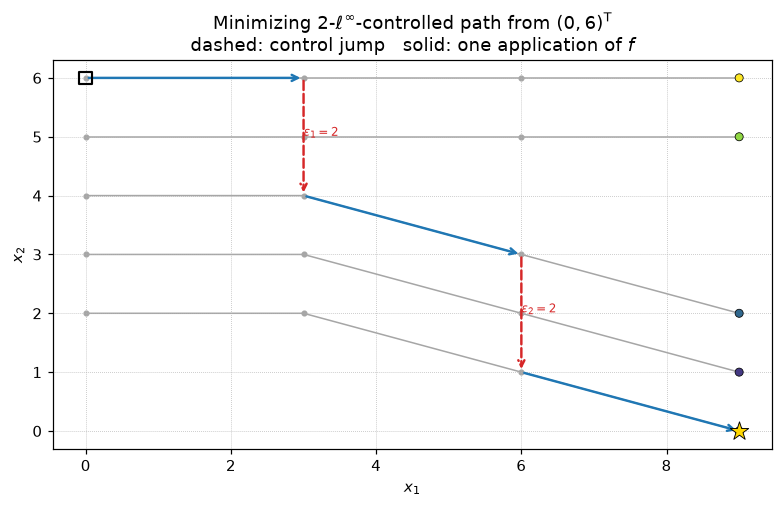

In [14]:
fig, ax = ec.plot_ensemble(adata, figsize=(7, 4.5), show_colorbar=False)
ec.plot_minimizing_path(adata, path, ax=ax)
ax.set_title(r"Minimizing $2$-$\ell^\infty$-controlled path from $(0,6)^{\mathsf{T}}$"
             "\n"
             r"dashed: control jump   solid: one application of $f$")
fig.savefig("fig_path.png", dpi=150, bbox_inches="tight")

The square marks the initial state, the star the terminal one. Dashed red arrows are control jumps of the stated magnitude; solid blue arrows are applications of the dynamics. This is a concrete *intervention schedule*: what to do, when, and how hard.

The path also reports the **residual** budget at each state. For $p = \infty$ it stays constant — the budget refreshes every step, which is why assertion (3) of Theorem 3.12 reads as it does. For finite $p$ the prefix has already spent part of the budget, so the residual is what remains.

In [15]:
path_1 = ec.minimizing_path(adata, 0, 2.0, problem=prob_1)
print("p=1   costs:", path_1["costs"].tolist(), " residual:", np.round(path_1["residual"], 3).tolist())
print("p=inf costs:", path["costs"].tolist(),   " residual:", np.round(path["residual"], 3).tolist())

p=1   costs: [0.0, 2.0, 0.0]  residual: [2.0, 2.0, 0.0, 0.0]
p=inf costs: [0.0, 2.0, 2.0]  residual: [2.0, 2.0, 2.0, 2.0]


## 5. The $-\varepsilon$ branch: what an adversary can force

Everything so far assumed control is used *for* you. Definition 14 asks the opposite question: if a control of the same budget were applied *against* you, how bad could the outcome get?

$$h_f^{-\varepsilon\text{-}\ell^p}(x) = \sup h\bigl([x]^{\varepsilon\text{-}\ell^p}_f \cap \operatorname{dom} h\bigr).$$

Pass a **negative** `eps` — including the signed zero `-0.0`, which is the $-0$ endpoint of the parameter domain $[-\infty,-0] \sqcup [0,\infty]$.

In [16]:
ec.control_effect(adata, [-0.0, -1.0, -2.0], problem=prob_inf)

pd.DataFrame({
    "best at eps=2 (h^{2})": adata.obs[ec.result_key(2.0, np.inf)],
    "no control (h^{0})": adata.obs[ec.result_key(0.0, np.inf)],
    "worst at eps=2 (h^{-2})": adata.obs[ec.result_key(-2.0, np.inf)],
}).head(8)

,best at eps=2 (h^{2}),no control (h^{0}),worst at eps=2 (h^{-2})
0,0.0,6.0,6.0
1,0.0,6.0,6.0
2,5.0,6.0,6.0
3,6.0,6.0,6.0
4,0.0,5.0,6.0
5,0.0,5.0,6.0
6,2.0,5.0,6.0
7,5.0,5.0,5.0


The three columns bracket each state: the best outcome control can secure, the outcome the uncontrolled dynamics deliver, and the worst an adversary can force. Their ordering is Lemma 3.7. A state where the bracket is wide is **volatile** — control matters a great deal there, for good or ill; a narrow bracket marks a state whose fate is already essentially decided.

## 6. The difference effect function: where control pays off

Absolute values conflate two things: states that are already good, and states where intervention helps. The difference isolates the second (Definitions 15 and 16):

$$h_f^{\Delta\varepsilon\text{-}\ell^p} = h_f^{\varepsilon\text{-}\ell^p} - h_f^{0\text{-}\ell^p} \le 0 ,$$

the improvement over doing nothing. A **large negative** value marks a state where a budget of $\varepsilon$ buys the most.

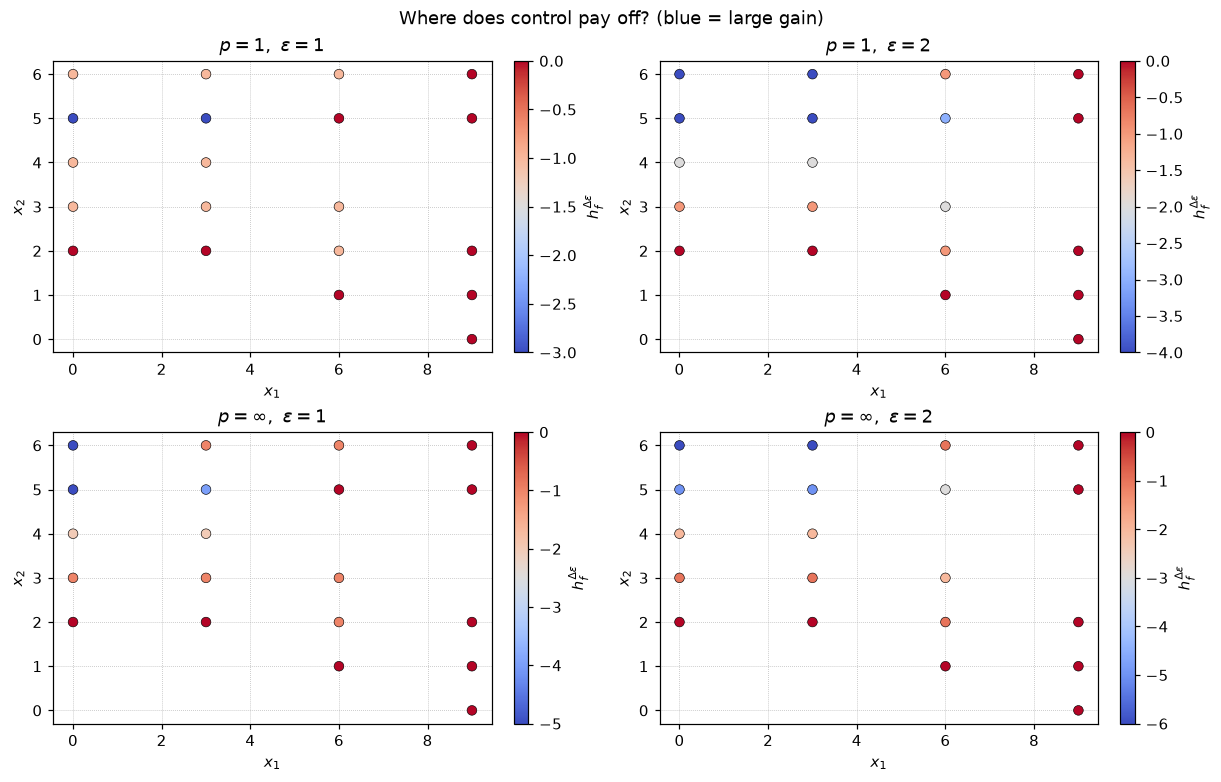

In [17]:
ec.effect_difference(adata, [1.0, 2.0], problem=prob_inf)
ec.effect_difference(adata, [1.0, 2.0], problem=prob_1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for j, eps in enumerate((1.0, 2.0)):
    for i, (p, prob) in enumerate((("1", prob_1), (r"\infty", prob_inf))):
        key = ec.result_key(eps, prob.p, prefix="effect_difference")
        ec.plot_effect(adata, key, ax=axes[i, j], cmap="coolwarm", center=0.0,
                       label=r"$h_f^{\Delta\varepsilon}$")
        axes[i, j].set_title(rf"$p={p},\ \varepsilon={eps:g}$")
fig.suptitle("Where does control pay off? (blue = large gain)")
fig.savefig("fig_difference.png", dpi=150, bbox_inches="tight")

## 7. The three-parameter filtration

Section 4.1 assembles the sublevel sets

$$H^{\ell^p}_{f,\varepsilon,\delta} = \{\, x \in X \mid h_f(p,\varepsilon,x) \le \delta \,\}$$

and Theorems 4.3 and 4.4 state that this family is a **filtration** in all three parameters: nested in $\delta$ by construction, in $\varepsilon$ because $h_f$ decreases in its second argument (Proposition 3.10), and in $p$ on the branch $\varepsilon \ge 0$ (Lemma 3.9). The three axes are precisely the three factors the paper sets out to relate — **cost norm**, **control strength**, **resulting value**.

In [18]:
filt = ec.filtration(prob_inf, ps=(1.0, 2.0, np.inf), n_epsilons=13)

print("masks shape (p, eps, delta, n):", filt.masks.shape)
print("nested in delta and eps      :", filt.is_filtration())
print("nested in p (for eps >= 0)   :", filt.is_filtration_in_p())

masks shape (p, eps, delta, n): (3, 13, 5, 20)
nested in delta and eps      : True
nested in p (for eps >= 0)   : True


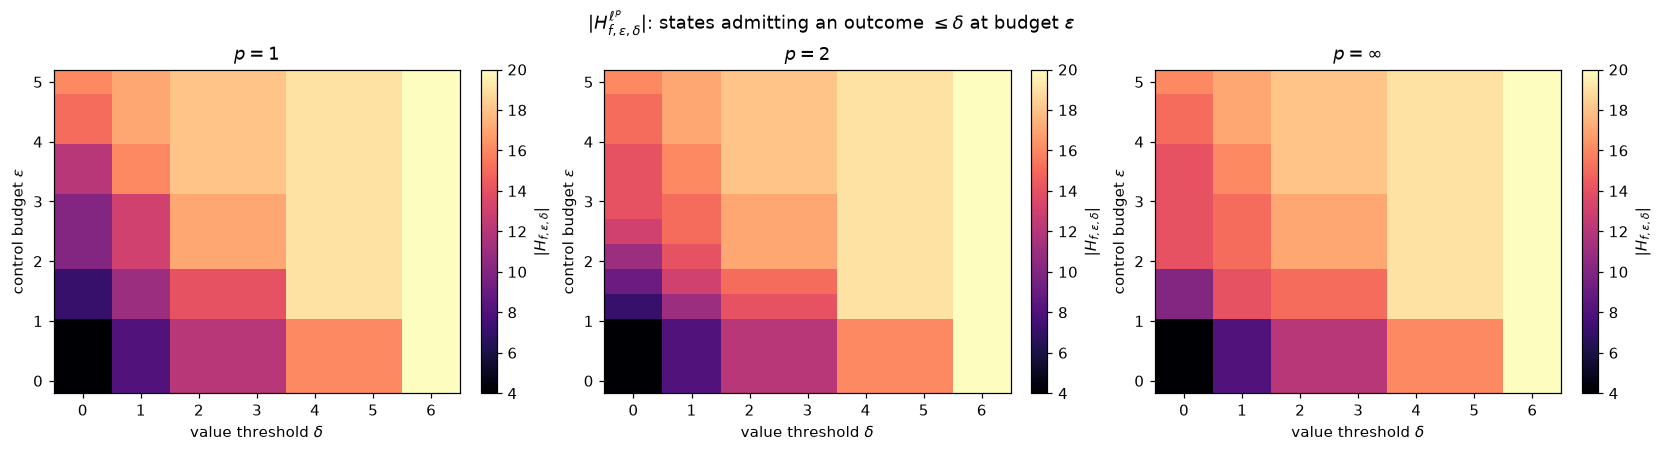

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for i in range(3):
    ec.plot_filtration_sizes(filt, p_index=i, ax=axes[i])
fig.suptitle(r"$|H^{\ell^p}_{f,\varepsilon,\delta}|$: states admitting an outcome $\leq \delta$ at budget $\varepsilon$")
fig.savefig("fig_filtration.png", dpi=150, bbox_inches="tight")

Each heatmap is one $p$-slice. Brightness grows to the right (a looser value threshold admits more states) and upward (a larger budget brings more states into reach); comparing panels shows the same monotonicity along $p$. Sweeping the parameters and watching *when* regions merge is what multi-parameter persistence quantifies.

`betti0` gives a topological rather than a cardinality summary: how many **connected components** each filtration member has, using the graph the dynamics induce. This counts the distinct controllable branches captured at each parameter triple.

In [20]:
b0 = filt.betti0(prob_inf)
pd.DataFrame(
    b0[-1][:6],
    index=[f"eps={e:.2f}" for e in filt.epsilons[:6]],
    columns=[f"delta={d:g}" for d in filt.deltas],
)

,delta=0,delta=1,delta=2,delta=5,delta=6
eps=0.00,1,2,3,4,5
eps=0.42,1,2,3,4,5
eps=0.83,1,2,3,4,5
eps=1.25,4,5,5,5,5
eps=1.67,4,5,5,5,5
eps=2.08,5,5,5,5,5


In [21]:
filt.to_frame().head(8)

,p,eps,delta,size
0,1.0,0.000000,0.0,4
1,1.0,0.000000,1.0,8
2,1.0,0.000000,2.0,12
3,1.0,0.000000,5.0,16
4,1.0,0.000000,6.0,20
5,1.0,0.416667,0.0,4
6,1.0,0.416667,1.0,8
7,1.0,0.416667,2.0,12


`to_frame()` gives a long table of $(p, \varepsilon, \delta, \text{size})$, convenient for handing the filtration to an external multi-parameter-persistence package. The `difference` variant filters by $h_f^{\Delta}$ instead (Theorem 4.4).

In [22]:
filt_diff = ec.filtration(prob_inf, ps=(1.0, np.inf), n_epsilons=9, kind="difference")
filt_diff.kind, filt_diff.is_filtration()

('difference', True)

## 8. A larger synthetic ensemble

The paper's example is small enough to check by hand. `datasets.branching_ensemble` gives something closer to real ensemble-forecast data: 60 members over 12 time steps that separate into two branches. The evaluation is the squared vertical offset of the terminal state, so **small is good** and control that steers a member toward the centre pays off.

(720, 2) layered
{'disjoint_domains': True, 'covers_X': True, 'preimage_decomposition': True, 'dom_h_fixed': True}


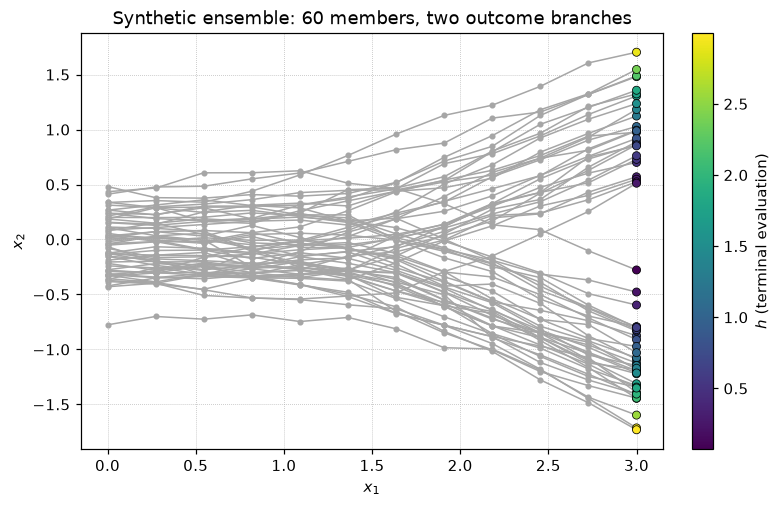

In [23]:
big = ec.datasets.branching_ensemble(n_members=60, n_steps=12, seed=0)
big_prob = ec.build_problem(big, p=np.inf)

print(big.shape, big_prob.solver)
print(ec.check_hypotheses(big, problem=big_prob))

fig, ax = ec.plot_ensemble(big, figsize=(7, 4.5))
ax.set_title("Synthetic ensemble: 60 members, two outcome branches")
fig.savefig("fig_big_ensemble.png", dpi=150, bbox_inches="tight")

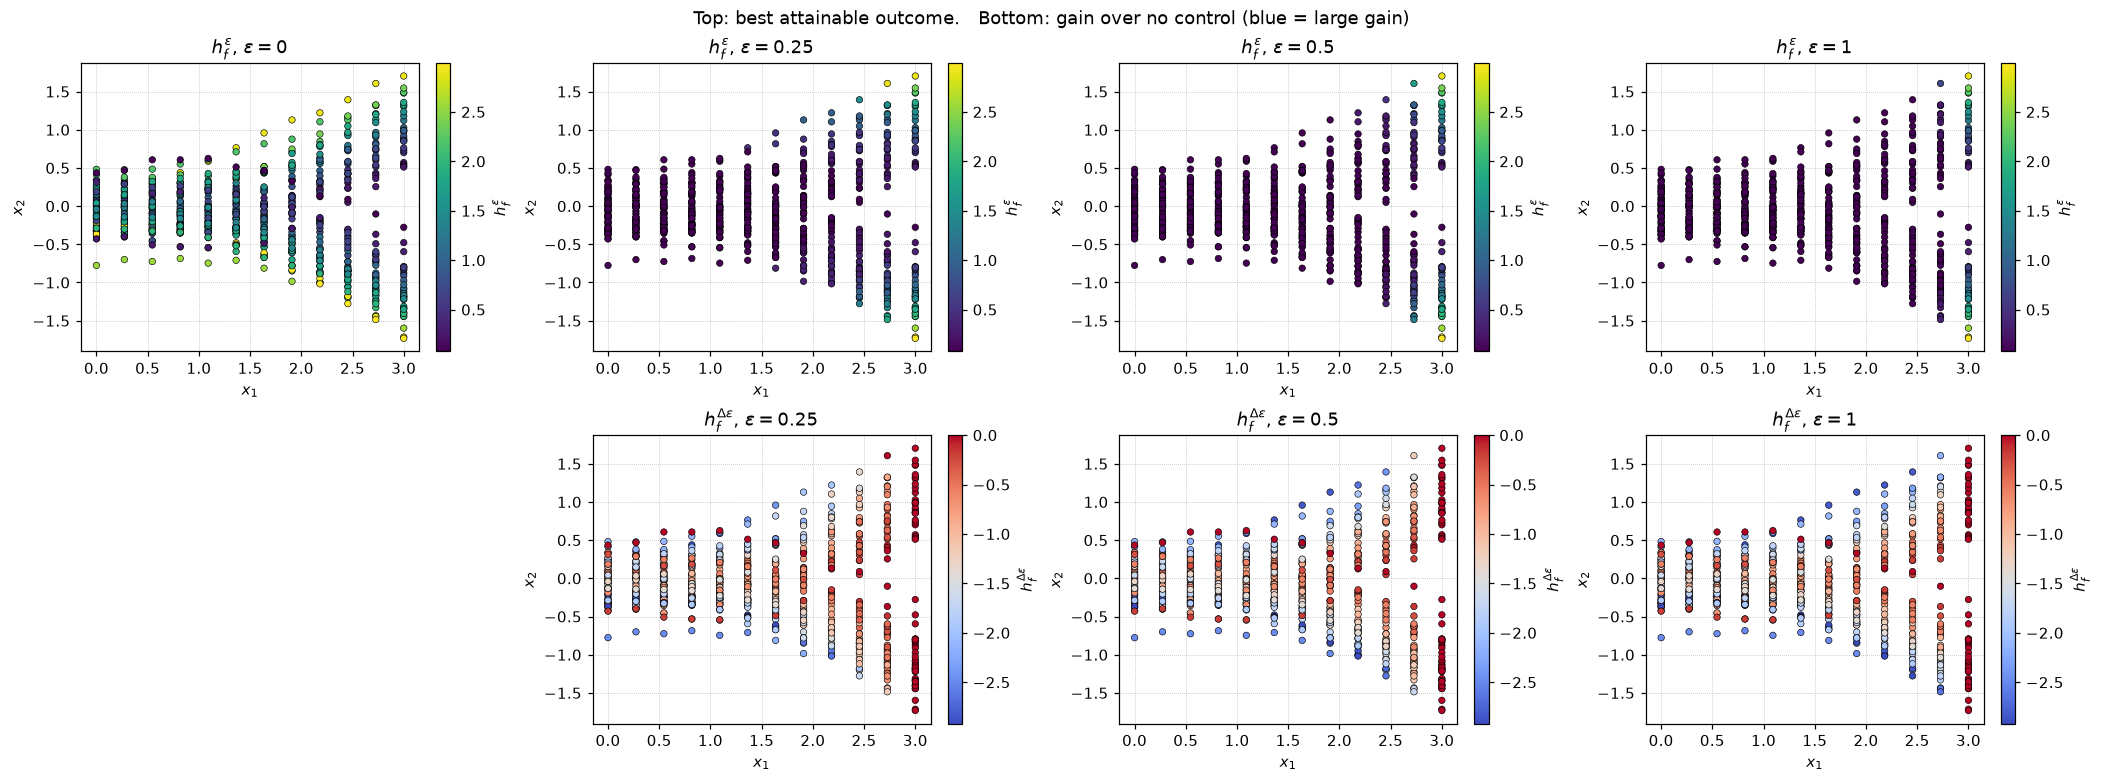

In [24]:
budgets = [0.0, 0.25, 0.5, 1.0]
ec.control_effect(big, budgets, problem=big_prob)
ec.effect_difference(big, budgets[1:], problem=big_prob)

fig, axes = plt.subplots(2, 4, figsize=(19, 7), constrained_layout=True)
for j, eps in enumerate(budgets):
    ec.plot_effect(big, ec.result_key(eps, np.inf), ax=axes[0, j], cmap="viridis",
                   label=r"$h_f^{\varepsilon}$", pointsize=18)
    axes[0, j].set_title(rf"$h_f^{{\varepsilon}}$, $\varepsilon={eps:g}$")
    if j == 0:
        axes[1, j].axis("off")
        continue
    ec.plot_effect(big, ec.result_key(eps, np.inf, prefix="effect_difference"),
                   ax=axes[1, j], cmap="coolwarm", center=0.0,
                   label=r"$h_f^{\Delta\varepsilon}$", pointsize=18)
    axes[1, j].set_title(rf"$h_f^{{\Delta\varepsilon}}$, $\varepsilon={eps:g}$")
fig.suptitle("Top: best attainable outcome.   Bottom: gain over no control (blue = large gain)")
fig.savefig("fig_big_grid.png", dpi=150, bbox_inches="tight")

The bottom row is the practical read-out. Early states, before the branches separate, show a large gain: a small nudge there still decides which branch the member follows. Late states show almost none — by then the outcome is locked in. That is the *control window*, and it is exactly what the difference effect function localizes.

An optimal intervention for one poorly-performing member:

member 52:  h without control = 2.996   ->   with budget 1.0 = 0.077
nonzero control inputs: {0: 0.007, 1: 0.008, 2: 0.004, 3: 0.004, 5: 0.01, 8: 0.01}


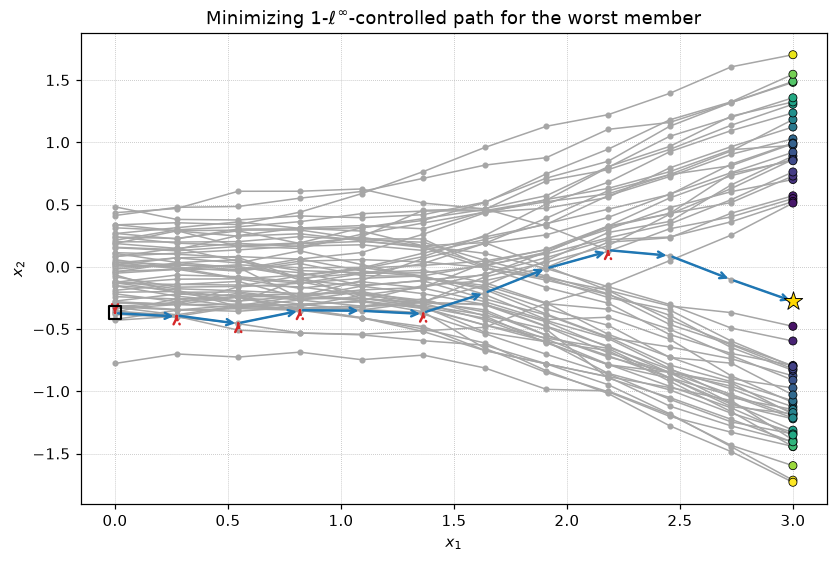

In [25]:
eff0 = big_prob.control_effect(0.0)
starts = np.nonzero((big.obs["time"].to_numpy() == 0))[0]
worst = int(starts[np.argmax(eff0[starts])])

p_big = ec.minimizing_path(big, worst, 1.0, problem=big_prob)
print(f"member {big.obs['seq_id'].iloc[worst]}:  h without control = {eff0[worst]:.3f}"
      f"   ->   with budget 1.0 = {p_big['value']:.3f}")
print("nonzero control inputs:",
      {int(k): round(float(c), 3) for k, c in enumerate(p_big["costs"]) if c > 1e-9})

fig, ax = ec.plot_ensemble(big, figsize=(7.5, 5), show_colorbar=False)
ec.plot_minimizing_path(big, p_big, ax=ax, annotate=False)
ax.set_title(r"Minimizing $1$-$\ell^\infty$-controlled path for the worst member")
fig.savefig("fig_big_path.png", dpi=150, bbox_inches="tight")

## Summary

| quantity | function | meaning |
|---|---|---|
| $h_f^{\varepsilon\text{-}\ell^p}$ | `control_effect(adata, eps)` | best outcome reachable with budget $\varepsilon$ |
| $h_f^{-\varepsilon\text{-}\ell^p}$ | `control_effect(adata, -eps)` | worst outcome an adversary can force |
| $h_f^{\Delta\varepsilon\text{-}\ell^p}$ | `effect_difference(adata, eps)` | gain over no control — where to intervene |
| $C^{\ell^p}_{h,f}(x,r)$ | `control_cost(adata)` | cheapest control securing an outcome $\le r$ |
| $R^{\ell^p}_{h,f}(\varepsilon,x)$ | `reachable_range(adata, x, eps)` | which outcomes are attainable |
| $\gamma$ | `minimizing_path(adata, x, eps)` | the intervention schedule realizing the optimum |
| $H^{\ell^p}_{f,\varepsilon,\delta}$ | `filtration(problem)` | three-parameter filtration for persistence |

**Practical notes.**

* Build one `ControlProblem` with `build_problem` and pass it as `problem=` everywhere — the shortest paths are then solved once and cached.
* `p = np.inf` caps each individual input; `p = 1` caps their total. These recover the $\varepsilon$- and $\varepsilon_\Sigma$-controlled paths of the earlier `epsbasin` framework.
* Supply a domain-specific cost via `adata.uns["cost_matrix"]`, `cost=<callable>`, or `metric=...`; use `time_aligned=False` to permit control jumps between different times.
* `np.inf` in a result means $\operatorname{dom} h$ is unreachable from that state at that budget — no outcome is evaluated on any orbit it can reach.